# DeepStomata — single-image minimal reproduction (detection + classification + aperture measurement)

**Paper:** Yosuke Toda, Shigeo Toh, Gildas Bourdais, Silke Robatzek, Dan Maclean, Toshinori Kinoshita,
*DeepStomata: Facial Recognition Technology for Automated Stomatal Aperture Measurement*,
bioRxiv 365098v1 (2018), doi:[10.1101/365098](https://doi.org/10.1101/365098) —
[full text](https://www.biorxiv.org/content/10.1101/365098v1.full)

**Code:** [totti0223/deepstomata @ commit e4f5dd5](https://github.com/totti0223/deepstomata/tree/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558) (MIT License)

**Scope of this notebook:** ONE author example image (`examples/1.jpg`, 2448×1920 px leaf-disk photo) processed with the authors' pretrained models:

1. detect stomata with the dlib HOG detector (`utils.py:123–227`)
2. classify each detection as open / partially_open / closed / false_positive with the CNN (`stomata_model.py`, weights `model.ckpt-5000`)
3. segment the pore of open/partially_open stomata and measure aperture, area etc. in µm (`utils.py:319–464`)
4. reproduce the author's CSV outputs and annotated image (`utils.py:505–740`)

This is a minimal demonstration, **not** a reproduction of the paper's dataset-level results (dose–response IC50/EC50, benchmark precision/recall, timing).

**Execution status:** validated end-to-end on Colab; final timings are recorded in the last cell and the full validation record is in the companion report.

---

**日本語概要:** このノートブックは、気孔自動計測手法 DeepStomata を、著者提供の学習済みモデルとサンプル画像 `examples/1.jpg`(2448×1920 px の葉ディスク写真)1 枚で体験する最小デモです。dlib の HOG 検出器で気孔を検出し、CNN が open / partially_open / closed / false_positive を判定、開いた気孔の孔をセグメンテーションして孔径(µm)などを計測し、著者コードと同じ形式の CSV と注釈付き画像を出力します。論文のデータセット全体の評価(投与反応の IC50/EC50、ベンチマーク精度、速度比較)は対象外です。

## Runtime & how to run

- **Runtime:** `Runtime → Change runtime type → CPU` (standard). GPU is not needed: the HOG detector runs on CPU and the CNN is tiny (~4.8 M parameters).
- **Run all:** `Runtime → Run all`. No interactive prompts, no restart required.
- **Expected duration:** ~15–20 min wall time, dominated by compiling dlib from source (~5–12 min). Measured timings are recorded in the last cell.
- **Downloads:** ~78 MiB total (CNN checkpoint 74 MiB, HOG detector 44 KiB, example image 0.7 MiB), all from the pinned GitHub commit.
- **Outputs:** `output/1_classification_count.csv`, `output/1_all.csv`, `output/1_all.jpg`, `output/1_stomata_position.jpg` under `/content/deepstomata_case`.

---

**日本語:** ランタイムは **CPU(標準)** で十分です(GPU 不要)。`ランタイム → すべて実行` で対話なしに完結します(合計 15–20 分程度。dlib のソースビルドが約 5–12 分で支配的。実測値は最後のセルに記録)。ダウンロードは約 78 MiB で、すべてピン止めした GitHub コミットから取得します。

In [1]:
import os, platform, sys, time
from datetime import datetime, timezone
from pathlib import Path

ROOT = Path('/content/deepstomata_case')
ROOT.mkdir(exist_ok=True)
os.chdir(ROOT)

# Wall-clock bookkeeping, reported in the last cell
TIMINGS = {}
T_NOTEBOOK_START = time.monotonic()

import numpy as np
import tensorflow as tf

print('Checked at UTC :', datetime.now(timezone.utc).isoformat())
print('Python         :', sys.version.split()[0], '|', platform.platform())
print('CPU cores      :', os.cpu_count(), '| GPU devices:', tf.config.list_physical_devices('GPU'))
print('TensorFlow     :', tf.__version__, '| NumPy:', np.__version__)
print('Working dir    :', os.getcwd())

Checked at UTC : 2026-09-26T04:56:09.629994+00:00
Python         : 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores      : 2 | GPU devices: []
TensorFlow     : 2.20.0 | NumPy: 2.1.3
Working dir    : /content/deepstomata_case


## 1. Environment setup

The author's `requirements.txt` pins a 2016-era stack (`tensorflow==0.12.0rc0`, `numpy==1.11.2`,
`scikit_image==0.14.0`) that no longer installs on modern Python. This notebook instead relies on
**Colab's preinstalled stack** (TensorFlow/Keras, NumPy, SciPy, scikit-image, OpenCV, Pillow,
matplotlib, pandas) and adds only **dlib**, which has no prebuilt PyPI wheel and is compiled from
source by pip (cmake is preinstalled on Colab). All legacy-format handling (TF1 checkpoint,
`scipy.misc.imresize`) is adapted in later cells and documented there.

The next cell compiles and installs dlib — it is the slowest step of the notebook.

---

**日本語:** 著者の `requirements.txt` は 2016 年当時の固定バージョン(TF 0.12 など)で現行環境に導入できないため、Colab 標準ライブラリを使用し、追加で **dlib のみ** ソースからビルドしてインストールします(約 5–12 分で、ここが最も時間のかかる工程です)。旧形式(TF1 チェックポイント等)への対応は後続のセルで明示的に行います。

In [2]:
import shutil, subprocess, sys, time

# dlib has no prebuilt wheel on PyPI, so pip compiles the C++ source (cmake is preinstalled on Colab)
assert shutil.which('cmake') is not None, 'cmake not found; cannot build dlib from source'

t0 = time.monotonic()
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'dlib==19.24.6'], check=True)
TIMINGS['dlib_install_s'] = round(time.monotonic() - t0, 1)

import dlib
print(f'dlib {dlib.__version__} installed in {TIMINGS["dlib_install_s"]} s')

dlib 19.24.6 installed in 4.0 s


## 2. Inputs and pretrained models (pinned sources, sha256-verified)

All inputs are downloaded inside this notebook from the authors' repository at a pinned commit and
verified by SHA-256 before use:

| File (repo path) | Role | Size | Source |
|---|---|---|---|
| `deepstomata/models/leafdisk161002_c_7.0.svm` | dlib HOG+SVM stomata detector | 44,688 B | [blob](https://github.com/totti0223/deepstomata/blob/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558/deepstomata/models/leafdisk161002_c_7.0.svm) |
| `deepstomata/models/model.ckpt-5000` | CNN classifier weights (TF1 checkpoint, single file) | 77,562,442 B | [blob](https://github.com/totti0223/deepstomata/blob/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558/deepstomata/models/model.ckpt-5000) |
| `examples/1.jpg` | example leaf-disk photo (2448×1920 px) | 699,080 B | [blob](https://github.com/totti0223/deepstomata/blob/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558/examples/1.jpg) |

Notes: the checkpoint's `.meta` graph file is not needed — the variable names are known from
`stomata_model.py`. The example image is one of the author-provided leaf-disk photographs
(Commelina benghalensis, BX43 objective + DP27 camera). Scale calibration `pixel_per_um = 2.88`
and the pore filtering criteria come from the author's `config.ini` (pinned commit).

---

**日本語:** 入力画像・HOG 検出器・CNN 重みはすべてピン止めしたコミットから取得し、SHA-256 で検証してから使います。`.meta`(グラフ定義)は不要です(変数名は `stomata_model.py` から既知)。較正値 2.88 px/µm と孔フィルタ基準は著者の `config.ini` 由来です。

In [3]:
import hashlib
import urllib.request

COMMIT = 'e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558'
RAW = f'https://raw.githubusercontent.com/totti0223/deepstomata/{COMMIT}/'
ASSETS = {
    # repo-relative path: (sha256, size in bytes)
    'deepstomata/models/leafdisk161002_c_7.0.svm': ('1c8aa41edf5dc9b30134dc992fc2d29d94f776d1bd0159c23ccaeb18370f09fe', 44688),
    'deepstomata/models/model.ckpt-5000': ('f5254868b74a3d96045d2580ca912a3c3f5aac3ad954b8ea1d48842a1f18c61e', 77562442),
    'examples/1.jpg': ('e1229c87c076cc373e29b2a2173d6ce385873f471021d1fb6d4a4386e9554995', 699080),
}

t0 = time.monotonic()
for rel, (sha, size) in ASSETS.items():
    dest = ROOT / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = ROOT / (rel + '.part')
    if dest.exists() and dest.stat().st_size == size:
        print(f'cached   ({size:>9,} B): {rel}')
        continue
    print(f'fetching {rel} ...')
    urllib.request.urlretrieve(RAW + rel, tmp)
    digest = hashlib.sha256(tmp.read_bytes()).hexdigest()
    assert digest == sha, f'sha256 mismatch for {rel}: got {digest}'
    assert tmp.stat().st_size == size, f'size mismatch for {rel}'
    tmp.rename(dest)
    print(f'verified ({size:>9,} B): {rel}')
TIMINGS['download_s'] = round(time.monotonic() - t0, 1)
print(f"total {sum(s for _, s in ASSETS.values()) / 1e6:.1f} MB in {TIMINGS['download_s']} s | commit {COMMIT}")

fetching deepstomata/models/leafdisk161002_c_7.0.svm ...


verified (   44,688 B): deepstomata/models/leafdisk161002_c_7.0.svm
fetching deepstomata/models/model.ckpt-5000 ...


verified (77,562,442 B): deepstomata/models/model.ckpt-5000
fetching examples/1.jpg ...


verified (  699,080 B): examples/1.jpg
total 78.3 MB in 3.0 s | commit e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558


## 3. CNN weights: TF1 checkpoint → Keras

The author's classifier graph (`stomata_model.py:tf_inference`) is:

`conv 3×3×32 → pool(3, stride 2) → conv 3×3×64 → pool → conv 3×3×128 → pool → conv 3×3×256 → pool → flatten(4096) → fc 1024 → fc 256 → fc 4 (logits)`

with variables stored in a TF1 checkpoint named `conv1/weights … fc7/biases`. The next cell
rebuilds exactly this graph in Keras and copies every tensor with
`tf.compat.v1.train.NewCheckpointReader` (no graph file needed — tensor shapes are asserted
against the rebuilt layers, finiteness is checked, and the total parameter count must equal the
hand-computed 4,847,172). Softmax is applied after inference at classification time, exactly like
the author's `stomata_stat_batch_classify`.

---

**日本語:** 著者の CNN(TF1 チェックポイント)を Keras で同じ構造として再構築し、`NewCheckpointReader` でテンソルを層ごとにコピーします。形状の一致・有限値・総パラメータ数(4,847,172)を検証します。softmax を推論後に適用する点も著者コードと同じです。

In [4]:
# TF1 checkpoint -> Keras. Kernel layout is [kh, kw, in, out] for convolutions and [in, out]
# for dense layers in BOTH TF1 and Keras, so tensors copy without transposition.
import numpy as np

reader = tf.compat.v1.train.NewCheckpointReader(str(ROOT / 'deepstomata/models/model.ckpt-5000'))

spec = [
    ('conv1', tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1')),
    ('pool1', tf.keras.layers.MaxPooling2D(3, strides=2, padding='same', name='pool1')),
    ('conv2', tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2')),
    ('pool2', tf.keras.layers.MaxPooling2D(3, strides=2, padding='same', name='pool2')),
    ('conv3', tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3')),
    ('pool3', tf.keras.layers.MaxPooling2D(3, strides=2, padding='same', name='pool3')),
    ('conv4', tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu', name='conv4')),
    ('pool4', tf.keras.layers.MaxPooling2D(3, strides=2, padding='same', name='pool4')),
    ('flatten', tf.keras.layers.Flatten(name='flatten')),
    ('fc5', tf.keras.layers.Dense(1024, activation='relu', name='fc5')),
    ('fc6', tf.keras.layers.Dense(256, activation='relu', name='fc6')),
    ('fc7', tf.keras.layers.Dense(4, name='fc7')),  # linear logits; softmax applied after inference
]
model = tf.keras.Sequential([layer for _, layer in spec])
model.build((None, 56, 56, 3))

for scope, layer in spec:
    if scope.startswith(('conv', 'fc')):
        w = reader.get_tensor(scope + '/weights')
        b = reader.get_tensor(scope + '/biases')
        kw, kb = layer.get_weights()
        assert w.shape == kw.shape and b.shape == kb.shape, f'{scope}: {w.shape} vs {kw.shape}'
        assert np.isfinite(w).all() and np.isfinite(b).all(), f'{scope}: non-finite values'
        layer.set_weights([w, b])
        print(f'{scope}: kernel {w.shape} bias {b.shape} -> copied')

n_params = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
assert n_params == 4847172, f'unexpected parameter count: {n_params}'

probe = model.predict(tf.zeros((1, 56, 56, 3)), verbose=0)
assert probe.shape == (1, 4) and np.isfinite(probe).all()
print(f'parameter count: {n_params:,} | logits on a zero image: {np.round(probe[0], 3)}')

conv1: kernel (3, 3, 3, 32) bias (32,) -> copied
conv2: kernel (3, 3, 32, 64) bias (64,) -> copied
conv3: kernel (3, 3, 64, 128) bias (128,) -> copied
conv4: kernel (3, 3, 128, 256) bias (256,) -> copied
fc5: kernel (4096, 1024) bias (1024,) -> copied
fc6: kernel (1024, 256) bias (256,) -> copied
fc7: kernel (256, 4) bias (4,) -> copied


parameter count: 4,847,172 | logits on a zero image: [-4.777 -0.909 -2.171  1.081]


## 4. Example input preview

`examples/1.jpg` is one of the author's sample leaf-disk photographs (2448×1920 px). The next cell
loads it as an RGB array (the author's `scipy.misc.imread` equivalent via Pillow) and previews the
full image and a central crop.

---

**日本語:** 著者提供のサンプル葉ディスク写真 `examples/1.jpg`(2448×1920 px)を読み込み、全体と中央部のクロップを表示します。読み込みは Pillow で RGB 配列として行います(旧 `scipy.misc.imread` の代替)。

image shape (H, W, C): (1920, 2448, 3)


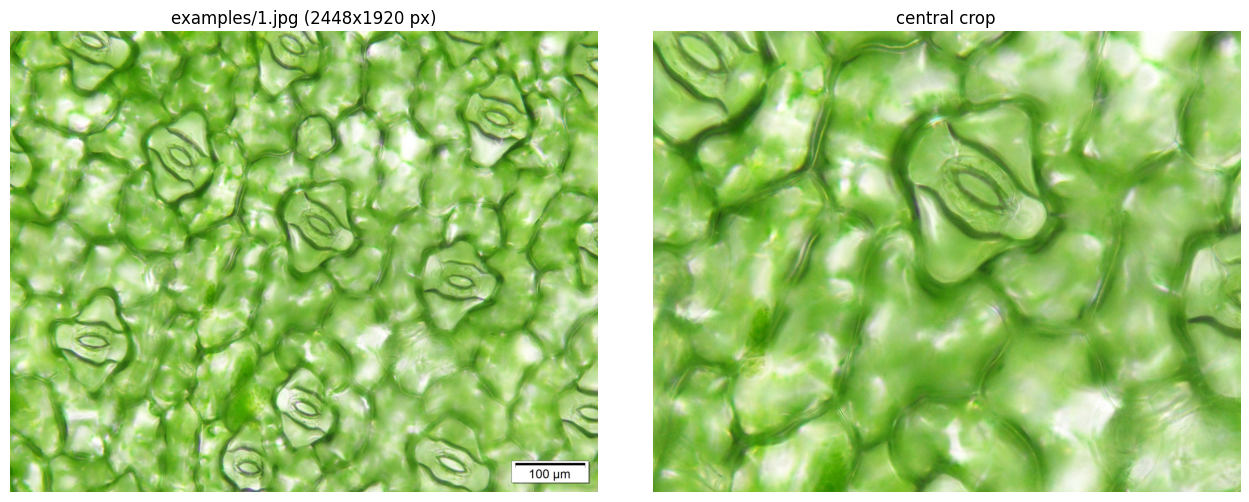

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = ROOT / 'examples/1.jpg'
image = np.asarray(Image.open(IMAGE_PATH).convert('RGB'))
print('image shape (H, W, C):', image.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(image)
axes[0].set_title(f'examples/1.jpg ({image.shape[1]}x{image.shape[0]} px)')
h, w = image.shape[:2]
axes[1].imshow(image[h // 4:3 * h // 4, w // 4:3 * w // 4])
axes[1].set_title('central crop')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Pipeline part 1 — detection and drawing helpers (verbatim port)

The next cell ports the author's helpers from `utils.py` (pinned commit `e4f5dd5`):

- `image_whitening` (utils.py:27–38) — per-image mean/variance normalization for the CNN input. Unchanged.
- `stomata_detector` (utils.py:123–227) — downscales the image to 512 px width, runs the dlib HOG detector, converts box coordinates back to the original scale, clamps only the coordinate that leaves the image, sorts left→right. Adaptations (behavior-preserving): accepts the RGB array instead of a file path (the author used `scipy.misc.imread`), and PIL BILINEAR replaces `scipy.misc.imresize`.
- `text_top_position` (utils.py:500–504) and `draw_stomata_position` (utils.py:228–267) — unchanged drawing helpers.
- `ini` mirrors the author's `config.ini`; values stay strings and are cast with `int()`/`float()` exactly like the author's `configparser` usage. OpenCV draws on RGB arrays here (as in the author's code), so color tuples follow cv2's BGR order on those arrays.

---

**日本語:** 著者の検出まわりの関数をそのまま移植します(白化処理、dlib 検出、はみ出し座標のクランプ、左→右ソート、描画ヘルパー)。`scipy.misc.imresize` → PIL BILINEAR、画像パス → RGB 配列受け取り、という 2 点のみ動作を変えない変更です。設定値は著者の `config.ini` の写しです。

In [6]:
import os
import cv2
import dlib
import numpy as np
from PIL import Image

# Author configuration values (config.ini at the pinned commit), kept as strings and cast with
# int()/float() exactly like the author's configparser usage.
ini = {
    'path': {'detector_path': str(ROOT / 'deepstomata/models/leafdisk161002_c_7.0.svm')},
    'open_criteria': {'min_area': '100', 'max_area': '6000', 'min_solidity': '0.8',
                      'min_major_axis_length': '40', 'margin': '0.2'},  # pixels / fractions
    'misc': {'pixel_per_um': '2.88'},  # BX43 objective + DP27 camera adapter
}

def image_whitening(img):
    # utils.py:27-38, verbatim (author's variable names kept)
    img = img.astype(np.float32)
    d, w, h = img.shape
    num_pixels = d * w * h
    mean = img.mean()
    variance = np.mean(np.square(img)) - np.square(mean)
    stddev = np.sqrt(variance)
    min_stddev = 1.0 / np.sqrt(num_pixels)
    scale = stddev if stddev > min_stddev else min_stddev
    img -= mean
    img /= scale
    return img

def stomata_detector(image, detector_path, detection_image_width=False):
    # utils.py:123-227. Adaptations (behavior-preserving): takes the RGB array instead of an image
    # path (the author used scipy.misc.imread), and PIL BILINEAR replaces scipy.misc.imresize.
    temp, detector_ext = os.path.splitext(detector_path)
    if (detector_ext != '.svm'):
        raise ValueError("extention of the detector must be .svm constructed by dlib hog.")
    detector = dlib.simple_object_detector(detector_path)

    height = image.shape[0]
    width = image.shape[1]

    if detection_image_width:
        ratio = width / detection_image_width
        height_det = int(round(height / ratio))
        width_det = int(round(width / ratio))

        scaled_image = np.asarray(Image.fromarray(image).resize((width_det, height_det), Image.Resampling.BILINEAR))

        dets = detector(scaled_image)
        scaled_dets = []
        original_dets = []

        # boxes converted back to the original scale may exceed the image; only the failing
        # coordinate is clamped (utils.py:175-193)
        for d in dets:
            scaled_dets.append([d.left(), d.top(), d.right(), d.bottom()])

            templeft = d.left() * ratio
            tempright = d.right() * ratio
            if d.left() <= 0:
                templeft = 1
            if d.right() * ratio > width:
                tempright = width

            tempbottom = d.bottom() * ratio
            temptop = d.top() * ratio
            if d.bottom() * ratio > height:
                tempbottom = height
            if d.top() < 0:
                temptop = 1
            original_dets.append([round(templeft), round(temptop), round(tempright), round(tempbottom)])

        print("\t", str(len(original_dets)) + " stomata detected")
        scaled_dets = sorted(scaled_dets, key=lambda i: i[0], reverse=False)
        original_dets = sorted(original_dets, key=lambda i: i[0], reverse=False)

        return image, scaled_image, original_dets, scaled_dets, ratio

    else:
        dets = detector(image)
        dets2 = []
        for d in dets:
            templeft = d.left()
            tempright = d.right()
            if d.left() <= 0:
                templeft = 1
            if d.right() > width:
                tempright = width
            tempbottom = d.bottom()
            temptop = d.top()
            if d.bottom() > height:
                tempbottom = height
            if d.top() < 0:
                temptop = 1
            dets2.append([round(templeft), round(temptop), round(tempright), round(tempbottom)])
        dets = sorted(dets2, key=lambda i: i[0], reverse=False)
        return image, dets

def text_top_position(d1, d3, y):
    # utils.py:500-504, verbatim
    if d1 < y * 0.2:
        return d3
    else:
        return d1

def draw_stomata_position(image, coords, text=True):
    # utils.py:228-267, verbatim (numbered black boxes used for the position figure)
    image_position = image.copy()
    if image_position.shape[0] > 1000:
        font_size = 2
        font_width = 8
        line_width = 3
    else:
        font_size = 0.5
        font_width = 1
        line_width = 1

    i = 1
    for d in coords:
        left = int(d[0])
        top = int(d[1])
        right = int(d[2])
        bottom = int(d[3])

        cv2.rectangle(image_position, (left, top), (right, bottom), (0, 0, 0), line_width)
        fixed_top = top
        if top < image_position.shape[0] * 0.4:
            fixed_top = bottom
        if text is True:
            cv2.putText(image_position, str(i), (left, fixed_top), cv2.FONT_HERSHEY_SIMPLEX, font_size, (0, 0, 0), font_width, cv2.LINE_AA)
        i += 1

    return image_position

print('ports ready: image_whitening, stomata_detector, text_top_position, draw_stomata_position')

ports ready: image_whitening, stomata_detector, text_top_position, draw_stomata_position


## 6. Pipeline part 2 — pore segmentation (verbatim port)

`pore_evaluator` (utils.py:319–464) measures the actual pore of open/partially_open stomata:
grayscale → Gaussian filter (σ=3) → local threshold (window 31, gaussian) → binary opening/closing
→ connected components. Regions are kept only if they pass the author's criteria from
`config.ini` (area 100–6000 px², solidity ≥ 0.8, major axis ≥ 40 px, centroid within the central
60% of the crop); remaining regions are hole-filled, relabeled, and if exactly one region remains
its contour (`new_coords`, xy order) and `regionprops` measurements are returned. Omitted: dead
code that `analyze()` never calls (verbose helpers, unused `gaussian()`, and the `fillPoly` on the
discarded `image_with_pore` copy). `scipy.ndimage.morphology.*` is now `scipy.ndimage.*` (same
functions, renamed in modern SciPy).

---

**日本語:** 開いた気孔の孔(pore)を局所二値化 + 連結成分解析で抽出し、著者の基準(面積 100–6000 px²、solidity ≥ 0.8、長軸 ≥ 40 px、重心は中心 60% 以内)でフィルタします。残った領域の輪郭と形状量を返します。`analyze()` から呼ばれないデッドコード(verbose 出力など)のみ省略しており、計算経路は原著どおりです。

In [7]:
from skimage.color import rgb2gray
from skimage.filters import threshold_local
from skimage import measure
from scipy import ndimage
import cv2
import numpy as np

def pore_evaluator(image, no, offset=(0, 0), o_ver=False):
    # utils.py:319-464, verbatim active path (see cell above for the omitted dead code)
    image_with_pore = image.copy()
    gray = rgb2gray(image)
    gray = ndimage.gaussian_filter(gray, 3)
    local_thresh = threshold_local(gray, 31, method="gaussian")
    image2 = gray > local_thresh

    image2 = ndimage.binary_opening(image2)   # scipy.ndimage.morphology.* -> scipy.ndimage.* (same functions)
    image2 = ndimage.binary_closing(image2)

    label_im, nb_labels = ndimage.label(image2)
    regionprops = measure.regionprops(label_im, intensity_image=gray)
    im_filt = label_im > 0

    height = image.shape[0]
    width = image.shape[1]
    open_regionprops = []
    n_o_regions = 0

    for prop in regionprops:
        # define criteria and mask away unwanted regions (config.ini open_criteria)
        if prop.area < int(ini['open_criteria']['min_area']) or \
         prop.area > int(ini['open_criteria']['max_area']) or \
         prop.solidity < float(ini['open_criteria']['min_solidity']) or \
         prop.major_axis_length < int(ini['open_criteria']['min_major_axis_length']) or \
         prop.centroid[0] < height * float(ini['open_criteria']['margin']) or \
         prop.centroid[0] > height * (1 - float(ini['open_criteria']['margin'])) or \
         prop.centroid[1] < width * float(ini['open_criteria']['margin']) or\
         prop.centroid[1] > width * (1 - float(ini['open_criteria']['margin'])):
            im_filt[label_im == prop.label] = False
        else:
            # retain
            open_regionprops.append(prop)
            n_o_regions += 1

    im_filt = ndimage.binary_fill_holes(im_filt)

    label_im2, nb_labels = ndimage.label(im_filt)
    regionprops = measure.regionprops(label_im2)
    n_o_regions = 0
    for prop in regionprops:
        n_o_regions += 1

    if n_o_regions == 1:
        new_coords = np.empty((0, 2), int)
        for coords in open_regionprops[0].coords:
            # xy to yx conversion for drawing in fillPoly function
            new_coords = np.append(new_coords, np.array([[coords[1], coords[0]]]), axis=0)

        stat = "open"
        return int(1), new_coords, open_regionprops, stat

    elif n_o_regions >= 2:
        # author's original selection loop, ported as-is (compares adjacent first-pass regions)
        l = 0
        temp = []
        while l < n_o_regions - 1:
            if open_regionprops[l].area > open_regionprops[l + 1].area:
                temp = []
                temp.append(open_regionprops[l])
                l += 1
            else:
                temp = []
                temp.append(open_regionprops[l + 1])
                l += 1

        new_coords = np.empty((0, 2), int)

        for coords in temp[0].coords:
            # xy to yx conversion for drawing in fillPoly function
            new_coords = np.append(new_coords, np.array([[coords[1], coords[0]]]), axis=0)
        stat = "open"
        return int(1), new_coords, temp, stat
    else:
        return int(0), int(0), int(0), int(0)

print('port ready: pore_evaluator')

port ready: pore_evaluator


## 7. Pipeline part 3 — detection + classification on `1.jpg`

The next cell defines `run_pipeline()`, mirroring `utils.analyze()` steps 2/4/5, and runs it on the
example image:

1. **Detection** (utils.py:520–526): the author's exact try/except — on failure it prints the error and "no stomata detected. skipping annotation"; zero detections skip everything downstream.
2. **Batch classification** (utils.py:549–556): each box is cropped, resized to 56×56, whitened, and classified in ONE forward pass. The author flattens crops and reshapes to (-1, 56, 56, 3) inside TF — stacking the whitened crops directly is numerically equivalent. Per class the author rounds probability×100 to 1 decimal and sorts by `int()` truncation (`utils.py:491–496`); that tie-break quirk is ported literally.
3. **Counts + count CSV** (utils.py:561–587): open/partially_open/closed/false_positive tallies written to `output/1_classification_count.csv` with the author's header and 'a+' append semantics.

---

**日本語:** `run_pipeline()` で検出→分類→件数集計を実行します。検出は著者と同じ try/except、分類は 56×56 に切り出して一括推論、確率は著者コードと同じく小数 1 桁に丸めて `int()` 切り捨て比較で最高クラスを選びます(同点時の挙動も含めて再現)。件数 CSV も著者形式のまま `output/` に書き出します。

In [8]:
OUT_DIR = ROOT / 'output'
OUT_DIR.mkdir(exist_ok=True)

def run_pipeline(image, name, count_csv_path):
    # utils.py:analyze() steps 2/4/5 for one image. Returns (boxes, results, softmax, counts);
    # counts = [open, partially_open, closed, false_positive]; zero detections -> ([], [], None, None).
    # 2. detection (utils.py:520-526, try/except ported verbatim)
    t0 = time.monotonic()
    original_dets = []
    try:
        image, scaled_image, original_dets, scaled_dets, ratio = stomata_detector(image, ini['path']['detector_path'], detection_image_width=512)
    except Exception as e:
        print(e)
        print("no stomata detected. skipping annotation")
    TIMINGS['detection_s'] = round(time.monotonic() - t0, 1)

    boxes = original_dets
    if len(boxes) == 0:
        return boxes, [], None, None

    # 4. batch classification (utils.py:549-556): crop -> 56x56 -> whitening -> one forward pass.
    #    The author flattens crops and reshapes to (-1, 56, 56, 3) inside TF; stacking whitened
    #    crops directly is numerically equivalent.
    t0 = time.monotonic()
    stomata_all = []
    for d in boxes:
        stomata = image[d[1]:d[3], d[0]:d[2]]
        stomata = np.asarray(Image.fromarray(stomata).resize((56, 56), Image.Resampling.BILINEAR))
        stomata = image_whitening(stomata)
        stomata_all.append(stomata.astype(np.float32))
    logits = model.predict(np.asarray(stomata_all), verbose=0)  # shape (n, 4)
    softmax = tf.nn.softmax(logits).numpy()

    # utils.py:490-496, verbatim: percentages rounded to 1 decimal, then sorted by int() truncation
    results = []
    for logit in softmax:
        logit = [round(n * 100, 1) for n in logit]
        logit = np.asarray(logit)
        result = [["open", logit[0]], ["closed", logit[1]], ["partially_open", logit[2]], ["false_positive", logit[3]]]
        result = sorted(result, key=lambda x: int(x[1]), reverse=True)
        results.append(result[0])
    TIMINGS['classification_s'] = round(time.monotonic() - t0, 1)

    # 5. count statistics + count CSV (utils.py:561-587, verbatim incl. 'a+' append semantics)
    open_count, close_count, popen_count, nolabel_count = 0, 0, 0, 0
    for result in results:
        if result[0] == "open":
            open_count += 1
        elif result[0] == "closed":
            close_count += 1
        elif result[0] == "partially_open":
            popen_count += 1
        elif result[0] == "false_positive":
            nolabel_count += 1

    csv_class_count = open(count_csv_path, 'a+')
    if os.stat(count_csv_path).st_size == 0:  # write header if empty
        csv_class_count.write("Image_name,open,partially_open,closed,false_positive\n")
    s = ",".join([name, str(open_count), str(popen_count), str(close_count), str(nolabel_count) + "\n"])
    csv_class_count.write(s)
    csv_class_count.close()

    counts = [open_count, popen_count, close_count, nolabel_count]
    return boxes, results, softmax, counts

t0 = time.monotonic()
boxes, results, softmax, counts = run_pipeline(image, IMAGE_PATH.stem, str(OUT_DIR / (IMAGE_PATH.stem + '_classification_count.csv')))
assert len(boxes) > 0, 'no stomata detected in the example image - pipeline cannot continue'
print(f"open: {counts[0]} | partially_open: {counts[1]} | closed: {counts[2]} | false_positive: {counts[3]} | total: {len(boxes)}")

	 9 stomata detected


open: 8 | partially_open: 0 | closed: 1 | false_positive: 0 | total: 9


## 8. Pipeline part 4 — per-region measurement (verbatim port)

The next cell reproduces `utils.analyze()` step 6 (utils.py:592–732) for every detected box. For
open/partially_open stomata it calls `pore_evaluator` inside the author's exact try/except; on
failure the CSV row is `<stat>_but_failed_to_detect_pore,0,0`. On success the author's measurements
are written verbatim:

- aperture µm = minor axis / 2.88, area µm² = area / 2.88², ratio = minor/major, centroids in px, eccentricity, solidity
- the column literally named `Long_axis_length(um)` actually contains the major axis **in pixels** (utils.py:658) — an author quirk, ported as-is
- closed rows are the author's 5-field `name,no,closed,0,0` rows; false_positive rows are not written; open/partially_open rows with zero valid regions write nothing

Drawing is deferred to the next cell (net-identical); everything else, including the aperture-text
logic with the author's bare except, is ported literally. All per-region state is collected in
`annotations` for the drawing/visualization cells, and measured rows additionally in `records`
for the summary table.

---

**日本語:** 検出領域ごとに孔の計測を実行します。開いた気孔では著者と同じ try/except で孔抽出し、失敗時は `_but_failed_to_detect_pore` 行を書き込みます。成功時は孔径 = 短軸/2.88 µm、面積 = 面積/2.88²、アスペクト比・重心・eccentricity・solidity を著者形式のまま CSV に書きます(列名 `Long_axis_length(um)` に画素単位の長軸が入る著者仕様の癖もそのまま再現)。closed は 5 フィールド行、false_positive は行なしも原著どおりです。

In [9]:
import math

# utils.py:592-732 for every detected box. CSV quirks are ported verbatim (see cell above).
name = IMAGE_PATH.stem
detail_csv_path = OUT_DIR / (name + '_all.csv')
csv_all = open(detail_csv_path, 'a+')
if os.stat(detail_csv_path).st_size == 0:  # write header if empty (utils.py:595-596)
    csv_all.write("Image_name,RegionNo.,Stat,Aperture(um),Area(um^2),Long_axis_length(um),Aperture/Long_axis_length(arbitrary),Centroid(X)(px),Centroid(Y)(px),Eccentricity(arbitrary),Solidity(arbitrary)\n")

base_image = image.copy()            # drawn in the next cell
image_all_annotated = image.copy()   # drawn in the next cell

q = 0
no = 1  # no. of all detected region (utils.py:604)
annotations = []  # per-det state for the drawing/visualization cells
records = []      # measured pore rows for the summary table

for d in boxes:  # analyze and record per stomata.
    stomata = image[d[1]:d[3], d[0]:d[2]]
    region_stat = results[q][0]
    percentage = results[q][1]  # kept for fidelity; unused below, as in utils.py:610
    fixed_top = text_top_position(d[1], d[3], image_all_annotated.shape[0])

    failed = False
    region_number = 0
    new_coords = None
    regionprops = []
    if region_stat == "open" or region_stat == "partially_open":
        if region_stat == "open":
            colors = (255, 0, 0)
        elif region_stat == "partially_open":
            colors = (255, 165, 0)
        try:
            region_number, new_coords, regionprops, stat = pore_evaluator(stomata, no, o_ver=False)
        except Exception as e:
            print(e)
            s = ",".join([name, str(no), region_stat + "_but_failed_to_detect_pore", str(0), str(0) + "\n"])
            csv_all.write(s)
            failed = True

    elif region_stat == "closed":
        colors = (135, 206, 235)
        s = ",".join([name, str(no), "closed", str(0), str(0) + "\n"])
        csv_all.write(s)

    else:  # false_positive
        colors = (100, 100, 100)

    um = "n.d."  # initialize um (utils.py:649)
    if region_number > 0:
        for n in regionprops:  # regionprops may contain multiple areas (utils.py:653)
            s = ",".join([
                name, str(no), region_stat,
                str(n.minor_axis_length / float(ini['misc']['pixel_per_um'])),
                str(n.area / float(ini['misc']['pixel_per_um']) ** 2),
                str(n.major_axis_length),
                str(n.minor_axis_length / n.major_axis_length),
                str(n.centroid[1]),
                str(n.centroid[0]),
                str(n.eccentricity),
                str(n.solidity) + "\n"
            ])
            csv_all.write(s)

            um = n.minor_axis_length / float(ini['misc']['pixel_per_um'])
            records.append({'RegionNo.': no, 'Stat': region_stat, 'Aperture_um': um,
                            'Area_um2': n.area / float(ini['misc']['pixel_per_um']) ** 2,
                            'Major_axis_px': n.major_axis_length,
                            'Aperture_per_major': n.minor_axis_length / n.major_axis_length,
                            'Centroid_X_px': n.centroid[1], 'Centroid_Y_px': n.centroid[0],
                            'Eccentricity': n.eccentricity, 'Solidity': n.solidity})

    # write stat and aperture text (utils.py:696-711, verbatim incl. the bare except)
    if region_stat == "closed":
        aperture = "0um"
    elif region_stat == "open" or region_stat == "partially_open":
        try:
            aperture = '%02.2f' % um + "um"
        except:
            um = "n.d."
            aperture = um + "um"
    else:
        um = "not measured"
        aperture = um
    print(region_stat, aperture, end=",")

    # adjust background size for text (utils.py:715-718)
    if region_stat == "open" or region_stat == "closed":
        pad = 150
    elif region_stat == "partially_open" or region_stat == "false_positive":
        pad = 250

    annotations.append({'box': d, 'stat': region_stat, 'colors': colors, 'fixed_top': fixed_top,
                        'pad': pad, 'aperture': aperture, 'failed': failed,
                        'new_coords': new_coords, 'regionprops': regionprops,
                        'region_number': region_number})

    no += 1
    q += 1

csv_all.close()
print()
print(f"pore rows written: {len(records)} of {len(boxes)} detections")

open 13.19um,closed 0um,open 13.78um,open 12.65um,open 11.67um,open 12.43um,open 11.21um,open 12.06um,

open 13.81um,
pore rows written: 8 of 9 detections


## 9. Pipeline part 5 — annotated image (verbatim port, drawing deferred into one pass)

The author draws directly during the measurement loop (utils.py:652–687, 721–734). Here the same
drawing is performed in one pass over the `annotations` collected above — per region the net
result is identical and the author's draw order is preserved: pore fill + minor-axis arrows, then
the class rectangle (thickness 3; the author's exception path draws 2 px and then 3 px on the same
box, net-equal to a single 3 px rectangle), then the filled color pad behind the text and the
stat/aperture labels on both `base_image` and `image_all_annotated`, and finally the author's 50/50
blend of the two. The result is saved as `output/1_all.jpg`.

---

**日本語:** 著者は計測ループ内で直接描画していますが、ここでは同じ描画を `annotations` に基づき 1 パスで実行します(1 領域あたりの最終結果は同一。塗りつぶし→矢印→矩形→文字パッド→ラベルの順序も原著どおり)。最後に著者コードと同じ 50/50 合成を行い `output/1_all.jpg` として保存します。

In [10]:
import math
import cv2

# Author drawing (utils.py:652-687, 721-734), deferred from the measurement loop into one pass.
for a in annotations:
    d = a['box']
    colors = a['colors']
    if a['region_number'] > 0:
        cv2.fillPoly(image_all_annotated, [a['new_coords']], colors, offset=(d[0], d[1]))
        for n in a['regionprops']:
            y0, x0 = n.centroid
            orientation = n.orientation
            # minor-axis end points (the aperture axis); the author draws double arrows both ways
            x2 = x0 - math.sin(orientation) * 0.5 * n.minor_axis_length
            y2 = y0 - math.cos(orientation) * 0.5 * n.minor_axis_length
            x3 = x0 + math.sin(orientation) * 0.5 * n.minor_axis_length
            y3 = y0 + math.cos(orientation) * 0.5 * n.minor_axis_length
            cv2.arrowedLine(base_image, (math.floor(d[0] + x3), math.floor(d[1] + y3)), (math.floor(d[0] + x2), math.floor(d[1] + y2)), (0, 0, 0), thickness=2, tipLength=0.3)
            cv2.arrowedLine(base_image, (math.floor(d[0] + x2), math.floor(d[1] + y2)), (math.floor(d[0] + x3), math.floor(d[1] + y3)), (0, 0, 0), thickness=2, tipLength=0.3)
            cv2.arrowedLine(image_all_annotated, (int(d[0] + x3), int(d[1] + y3)), (int(d[0] + x2), int(d[1] + y2)), (0, 0, 0), thickness=2, tipLength=0.3)
            cv2.arrowedLine(image_all_annotated, (int(d[0] + x2), int(d[1] + y2)), (int(d[0] + x3), int(d[1] + y3)), (0, 0, 0), thickness=2, tipLength=0.3)

    # class rectangle: thickness 3 (see cell above for the 2px+3px -> 3px note)
    cv2.rectangle(image_all_annotated, (d[0], d[1]), (d[2], d[3]), colors, 3)

    # filled color pad behind the text, on image_all_annotated only (utils.py:721)
    cv2.rectangle(image_all_annotated, (d[0], a['fixed_top'] - 50), (d[0] + a['pad'], a['fixed_top'] + 25), colors, -1)
    cv2.putText(base_image, a['stat'], (d[0], a['fixed_top'] - 25), cv2.FONT_HERSHEY_TRIPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)
    cv2.putText(image_all_annotated, a['stat'], (d[0], a['fixed_top'] - 25), cv2.FONT_HERSHEY_TRIPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)
    cv2.putText(base_image, a['aperture'], (d[0], a['fixed_top'] + 10), cv2.FONT_HERSHEY_TRIPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)
    cv2.putText(image_all_annotated, a['aperture'], (d[0], a['fixed_top'] + 10), cv2.FONT_HERSHEY_TRIPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)

# utils.py:733-734, verbatim blend
alpha = 0.5
cv2.addWeighted(image_all_annotated, alpha, base_image, 1 - alpha, 0, image_all_annotated)

# the author saved via scipy.misc.imsave; PIL save with quality=95 keeps JPEG detail
annotated_path = OUT_DIR / (name + '_all.jpg')
Image.fromarray(image_all_annotated).save(annotated_path, quality=95)
print('saved:', annotated_path)

saved: /content/deepstomata_case/output/1_all.jpg


## 10. Result figures and per-region gallery

Three views of the same result plus a numbered gallery of every detection crop (each titled with
its CNN class). The position figure reuses the author's `draw_stomata_position` output (their
`imsave` call for it was commented out at utils.py:537; showing/saving it is our visualization
choice). The crop gallery replaces the author's per-crop files written by
`crop_and_save_stomata_images` (utils.py:268–274) — same crops, presented inline.

---

**日本語:** 同じ結果を 3 つの視点(検出位置図/全注釈図/文字のみ図)で表示し、さらに全検出領域の切り出し画像を番号付きギャラリーで示します。位置図は著者の `draw_stomata_position` の出力(著者は保存をコメントアウト済み、ここでは表示・保存として使用)、切り出しギャラリーは著者の `crop_and_save_stomata_images` の代替(同じ切り出しをインライン表示)です。

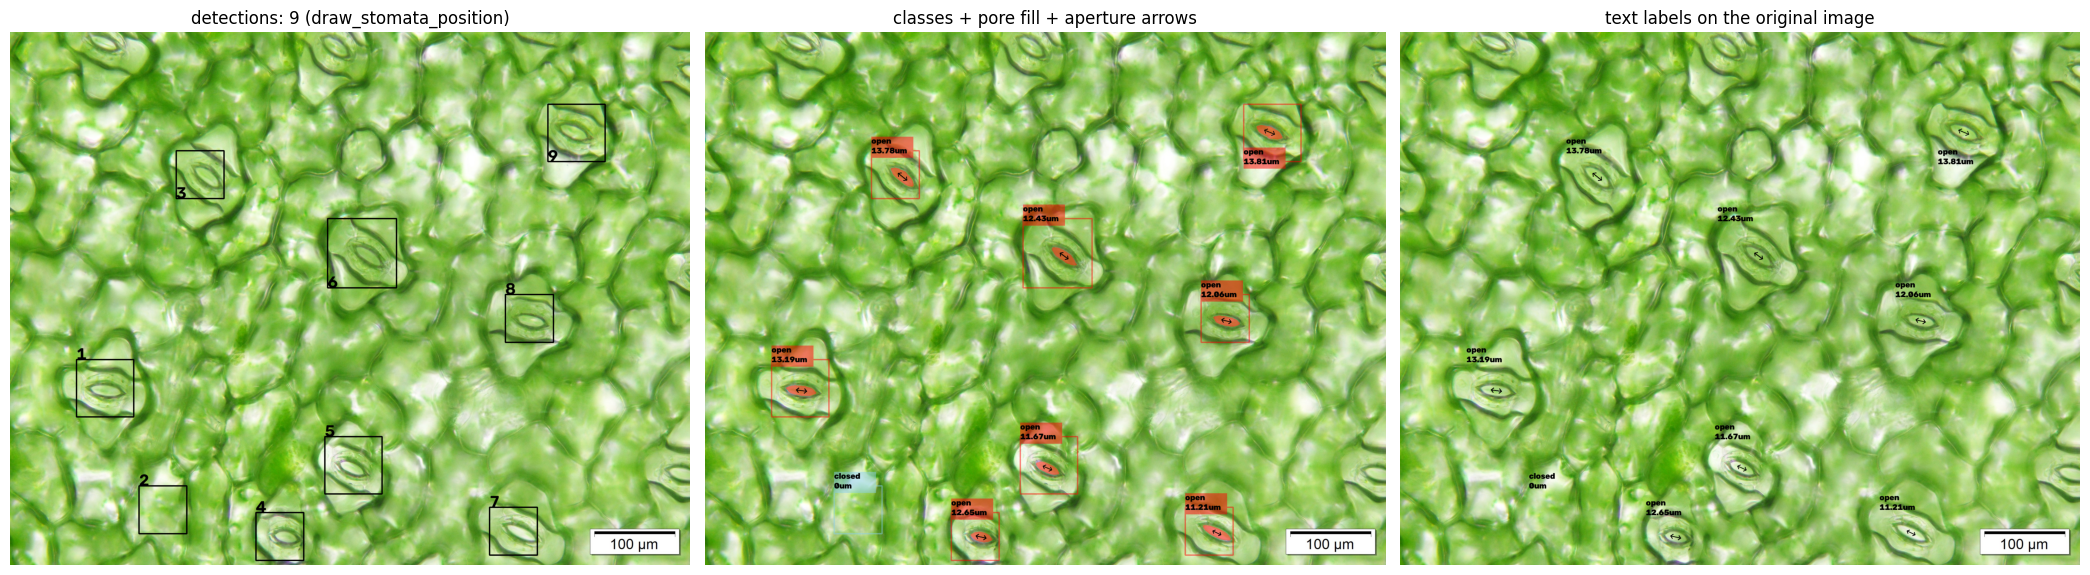

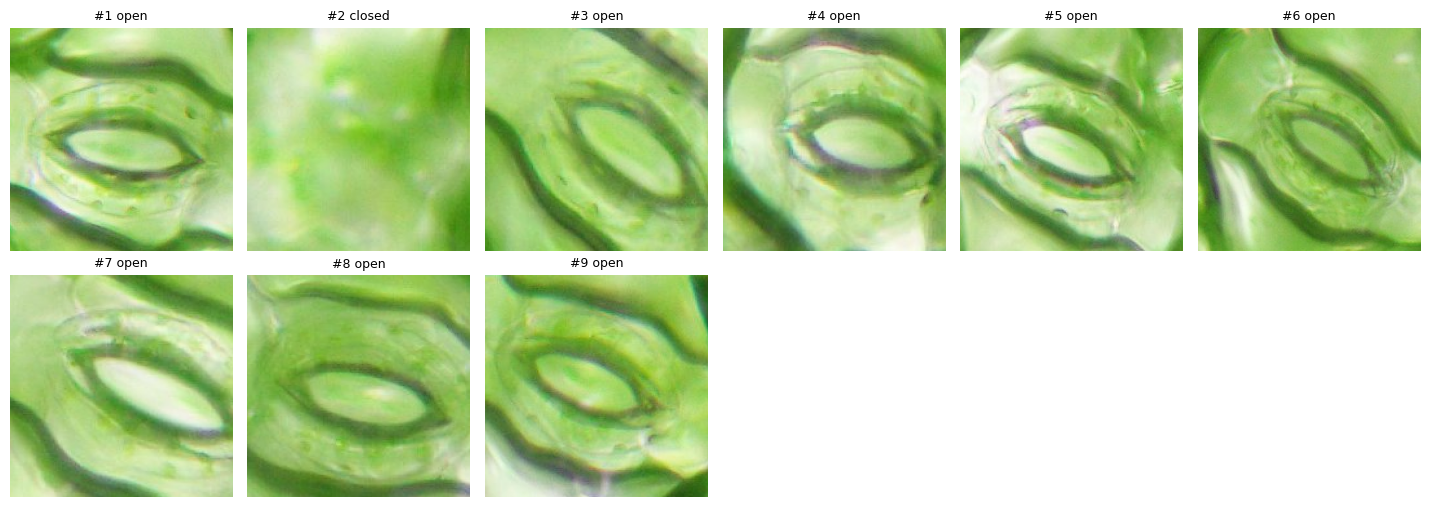

saved: /content/deepstomata_case/output/1_stomata_position.jpg


In [11]:
import math
import matplotlib.pyplot as plt

# position figure: author's draw_stomata_position output
image_with_position = draw_stomata_position(image, boxes)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes[0].imshow(image_with_position)
axes[0].set_title(f'detections: {len(boxes)} (draw_stomata_position)')
axes[1].imshow(image_all_annotated)
axes[1].set_title('classes + pore fill + aperture arrows')
axes[2].imshow(base_image)
axes[2].set_title('text labels on the original image')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

# numbered crop gallery, each titled with the CNN class (replaces the author's per-crop files)
ncols = 6
nrows = math.ceil(len(boxes) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.6 * nrows))
axes = np.asarray(axes).reshape(-1)
for idx, d in enumerate(boxes):
    axes[idx].imshow(image[d[1]:d[3], d[0]:d[2]])
    axes[idx].set_title(f"#{idx + 1} {results[idx][0]}", fontsize=9)
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

position_path = OUT_DIR / (name + '_stomata_position.jpg')
Image.fromarray(image_with_position).save(position_path, quality=95)
print('saved:', position_path)

## 11. Interpretation

- The counts printed above mirror the author's `*_classification_count.csv` (open / partially_open / closed / false_positive) and the measurements table mirrors `*_all.csv`. Apertures are reported in µm using the author's calibration of **2.88 px/µm** (BX43 objective + DP27 camera adapter, `config.ini`), so for this camera setup the numbers are directly comparable to the paper's outputs for single leaf-disk photographs.
- Per the paper, the pore minor axis (aperture) and pore area are the biologically meaningful quantities; the major axis stays in px only for fidelity with the author's CSV.
- **Differences from the paper:** this run uses one example image and the authors' pretrained 2016 models as-is, with a TF1→Keras weight conversion; the paper additionally reports dose–response curves (ABA / fusicoccin), benchmark precision/recall (0.954 / 0.940 on their test set) and a ~80× speed-up over manual measurement — none of that is re-evaluated here.
- A prior historical run of this same notebook processed all 11 author examples (114 detections, 89 pores); those numbers belong to that run, not to this one.

**References:** bioRxiv 365098v1 (doi:10.1101/365098); repo commit `e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558` (MIT License); dlib 19.24.6.

---

**日本語:** 上記の件数は著者の `*_classification_count.csv`、計測表は `*_all.csv` に対応し、孔径等は著者の較正値 2.88 px/µm(BX43 + DP27)で µm 換算しているため、このカメラ設定では論文の単一画像出力と直接比較可能です。本ランは 1 枚のサンプルと事前学習済みモデルの利用のみで、論文の投与反応曲線やベンチマーク精度(適合率 0.954/再現率 0.940)・速度比較(~80 倍)は再評価していません。

In [12]:
import pandas as pd

summary = pd.DataFrame(records)
if len(summary) > 0:
    display(summary.round(2))
else:
    print('no pore rows were measured')

# hard invariants of this run
assert len(boxes) == len(results) == len(annotations)
assert softmax.shape == (len(boxes), 4) and np.isfinite(softmax).all()
assert np.allclose(softmax.sum(axis=1), 1.0, atol=1e-5)
assert all(0 <= d[0] < d[2] <= image.shape[1] and 0 <= d[1] < d[3] <= image.shape[0] for d in boxes)

n_lines_all = len(open(detail_csv_path).read().strip().splitlines()) - 1  # minus header
n_failed = sum(1 for a in annotations if a['failed'])
expected_rows = counts[2] + len(records) + n_failed
assert n_lines_all == expected_rows, f'{name}_all.csv rows {n_lines_all} != closed {counts[2]} + measured {len(records)} + failed {n_failed}'
n_lines_count = len(open(OUT_DIR / (name + '_classification_count.csv')).read().strip().splitlines()) - 1
assert n_lines_count == 1, f'unexpected count csv rows: {n_lines_count}'
print(f"{name}_all.csv data rows: {n_lines_all} (= closed {counts[2]} + measured {len(records)} + failed {n_failed})")
print(f"{name}_classification_count.csv data rows: {n_lines_count}")

if len(summary) > 0:
    ap = summary['Aperture_um']
    if (ap >= 100).any():
        print('WARNING: aperture >= 100 um measured - check plausibility/scale calibration')
    else:
        print('aperture plausibility check (all < 100 um): OK')
    print(f"aperture um: min {ap.min():.1f} / median {ap.median():.1f} / max {ap.max():.1f}")

TIMINGS['total_s'] = round(time.monotonic() - T_NOTEBOOK_START, 1)
print('stage timings (s):', TIMINGS)

,RegionNo.,Stat,Aperture_um,Area_um2,Major_axis_px,Aperture_per_major,Centroid_X_px,Centroid_Y_px,Eccentricity,Solidity
0,1,open,13.19,316.84,111.49,0.34,107.88,111.73,0.94,0.85
1,3,open,13.78,311.78,103.46,0.38,112.23,93.63,0.92,0.86
2,4,open,12.65,233.65,78.23,0.47,107.74,88.14,0.88,0.90
3,5,open,11.67,276.21,89.77,0.37,97.90,113.72,0.93,0.96
4,6,open,12.43,306.11,106.76,0.34,147.68,135.27,0.94,0.88
5,7,open,11.21,334.08,109.46,0.29,114.08,92.16,0.96,0.97
6,8,open,12.06,303.22,96.47,0.36,91.58,95.67,0.93,0.95
7,9,open,13.81,309.49,102.85,0.39,93.67,100.81,0.92,0.86


1_all.csv data rows: 9 (= closed 1 + measured 8 + failed 0)
1_classification_count.csv data rows: 1
aperture plausibility check (all < 100 um): OK
aperture um: min 11.2 / median 12.5 / max 13.8
stage timings (s): {'dlib_install_s': 4.0, 'download_s': 3.0, 'detection_s': 0.4, 'classification_s': 0.2, 'total_s': 22.2}


## 12. Optional: extend to the remaining author examples

By default the notebook ends above. Setting the flag in the next cell to `True` before Run all
additionally downloads `examples/2.jpg … examples/11.jpg` (~6.5 MB, sha256-verified), runs the same
`run_pipeline` on each, and appends one row per image to a per-image count CSV — the author's
directory mode (utils.py:97–122 feeding the `analyze()` loop), without per-image figures to keep
this demo light.

---

**日本語:** 既定ではここで終了です。次のセルのフラグを `True` にして実行すると、著者のサンプル `2.jpg … 11.jpg`(約 6.5 MB)を追加ダウンロードし、同じ `run_pipeline` で処理して画像ごとの件数 CSV に追記します(著者のディレクトリモード相当。図は省略)。

In [13]:
RUN_BATCH = False  # set True to additionally process examples/2.jpg ... examples/11.jpg (~6.5 MB)

EXTRA_ASSET_SHA256 = {  # verification hashes for the optional examples (pinned commit)
    'examples/2.jpg': '1097c85d3c68b1c7c7b8f8326e362700af7f35a99d1e814d5087749107c9f01c',
    'examples/3.jpg': '9ac53deb3bb4160b83655f5b096c80cb0caaff0eb9dd11b65c8f73f9f8c7f00b',
    'examples/4.jpg': '0a0cda66de37fe3e09de1ffdc0b127bc1f9203ebd048201e34825269b726a974',
    'examples/5.jpg': 'bb5ca7f54c9ea229c44975b6e456a64960c952a30ad64ac871664bab1136ae73',
    'examples/6.jpg': '369d034d8cc2a8b2d2e6c6262ee13bd6892bea5f343ba3ec560fc36560ff25f5',
    'examples/7.jpg': 'd8254f2f3eef7e9ffcdf7f74e7a7797070968bcf3bbda79ce3f146a62c38484f',
    'examples/8.jpg': '280c05b8097ca9ef5be70fea1f850b8a63f8ab91c45a68f9a9b5c6df4c11e7e1',
    'examples/9.jpg': 'c0e66127fdf686c3c53d57fb02061e92cc90d3be89ed87918a206fceec56bf5d',
    'examples/10.jpg': '257bda164e9db726811eab1cb31806bdd1c449a6b3378738abc27a4ca01211fe',
    'examples/11.jpg': '32a679be711da4db9b9eac8e43c6515d260886e3b2f8c82422b65dca3ff79e06',
}

if RUN_BATCH:
    for i in range(2, 12):
        rel = f'examples/{i}.jpg'
        dest = ROOT / rel
        if not dest.exists():
            urllib.request.urlretrieve(RAW + rel, dest)
        digest = hashlib.sha256(dest.read_bytes()).hexdigest()
        assert digest == EXTRA_ASSET_SHA256[rel], f'sha256 mismatch for {rel}'
        img = np.asarray(Image.open(dest).convert('RGB'))
        b, r, sm, c = run_pipeline(img, str(i), str(OUT_DIR / (str(i) + '_classification_count.csv')))
        print(f"{rel}: open {c[0]} | partially_open {c[1]} | closed {c[2]} | false_positive {c[3]} | total {len(b)}")
else:
    print('batch disabled (RUN_BATCH = False); the single-image demo is complete')

batch disabled (RUN_BATCH = False); the single-image demo is complete
